In [114]:
import pandas as pd
import numpy as np

from sklearn.metrics import roc_auc_score
from sklearn.model_selection import StratifiedKFold, KFold

from scipy.stats import ks_2samp

from xgboost import XGBClassifier

import shap

import matplotlib.pyplot as plt 

In [115]:
df =  pd.read_csv("datasets/kingametric_credit_risk.csv")

In [116]:
df.shape

(8744, 45)

In [117]:
df["emi_to_income"] = df["Total_EMI_per_month"] / df["Monthly_Inhand_Salary"]
df["debt_to_income"] = df["Outstanding_Debt"] / df["Annual_Income"]

df["Annual_Income"] = np.log1p(df["Annual_Income"])
df["Outstanding_Debt"] = np.log1p(df["Outstanding_Debt"])

In [118]:
df.shape

(8744, 47)

In [119]:
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.fillna(df.median(numeric_only=True), inplace=True)

In [120]:
cat_cols = ["Payment_of_Min_Amount", "Credit_Mix", "Payment_Behaviour", "Borrower_Tier"]

df[cat_cols] = df[cat_cols].astype("category")

In [121]:
X = df.drop(columns=["Default_Flag"], axis=1)
y = df["Default_Flag"]

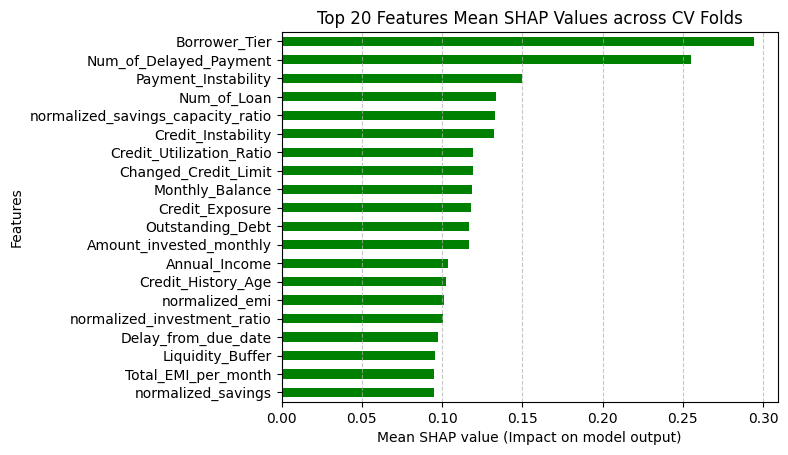

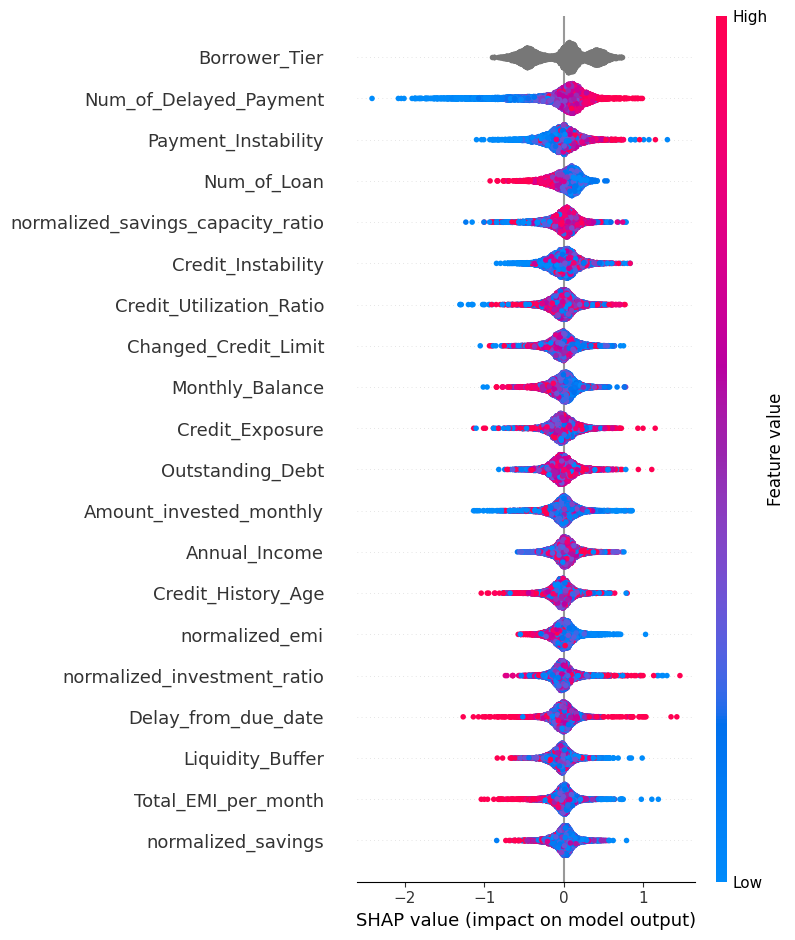

In [122]:
folds = KFold(n_splits=7, shuffle=True, random_state=42)
shap_values_list = []

for train_idx, val_idx in folds.split(X):

    xgb_m = XGBClassifier(enable_categorical=True, tree_method="hist").fit(X.iloc[train_idx], y.iloc[train_idx])

    explainer = shap.TreeExplainer(xgb_m)
    shap_fold = explainer.shap_values(X.iloc[val_idx])
    shap_values_list.append(shap_fold)

all_shap = np.vstack(shap_values_list)
mean_shap = np.abs(all_shap).mean(axis=0)

feature_importance = pd.Series(mean_shap, index=X.columns).sort_values(ascending=False)

#print("Top Features - Mean Absolute SHAP values:")
#print(feature_importance)

plt.Figure(figsize=(10, 6))
feature_importance.head(20).plot(kind="barh", color="green").invert_yaxis()
plt.title("Top 20 Features Mean SHAP Values across CV Folds")
plt.xlabel("Mean SHAP value (Impact on model output)")
plt.ylabel("Features")
plt.grid(axis="x", linestyle="--", alpha=0.7)
plt.show()

shap.summary_plot(all_shap, X.iloc[np.concatenate([v for _, v in folds.split(X)])])

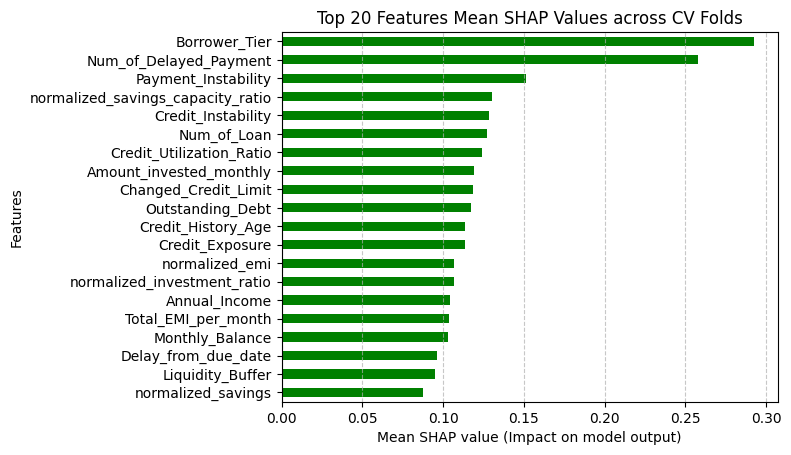

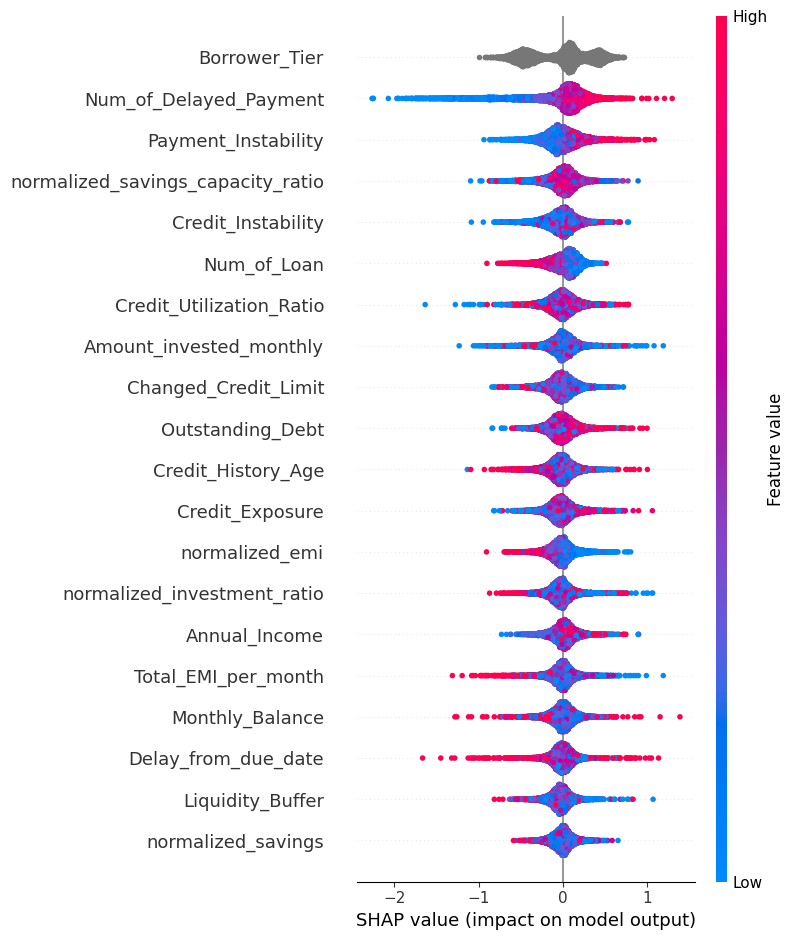

In [123]:
folds = StratifiedKFold(n_splits=7, shuffle=True, random_state=42)
shap_values_list = []

for train_idx, val_idx in folds.split(X,y):

    xgb_m = XGBClassifier(enable_categorical=True, tree_method="hist").fit(X.iloc[train_idx], y.iloc[train_idx])

    explainer = shap.TreeExplainer(xgb_m)
    shap_fold = explainer.shap_values(X.iloc[val_idx])
    shap_values_list.append(shap_fold)

all_shap = np.vstack(shap_values_list)
mean_shap = np.abs(all_shap).mean(axis=0)

feature_importance = pd.Series(mean_shap, index=X.columns).sort_values(ascending=False)

#print("Top Features - Mean Absolute SHAP values:")
#print(feature_importance)

plt.Figure(figsize=(10, 6))
feature_importance.head(20).plot(kind="barh", color="green").invert_yaxis()
plt.title("Top 20 Features Mean SHAP Values across CV Folds")
plt.xlabel("Mean SHAP value (Impact on model output)")
plt.ylabel("Features")
plt.grid(axis="x", linestyle="--", alpha=0.7)
plt.show()

shap.summary_plot(all_shap, X.iloc[np.concatenate([v for _, v in folds.split(X,y)])])

In [124]:
scale_pos_weight = len(y[y==0]) / len([y==1])

folds = KFold(n_splits=7, shuffle=True, random_state=42)

auc_scores = []
ks_scores = []

for train_idx, val_idx in folds.split(X):

    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    model = XGBClassifier(n_estimators=500,
    max_depth=4,
    learning_rate=0.03,
    subsample=0.8,
    scale_pos_weight=scale_pos_weight,
    colsample_bytree=0.8,
    min_child_weight=5,
    gamma=0.1,
    reg_alpha=0.5,
    enable_categorical=True, 
    tree_method="hist",
    reg_lambda=1.5,
    random_state=42)
    
    model.fit(X_train, y_train)

    # Predict probabilities
    y_prob = model.predict_proba(X_val)[:,1]

    # AUC
    auc = roc_auc_score(y_val, y_prob)
    auc_scores.append(auc)

    # KS Statistic
    ks = ks_2samp(
        y_prob[y_val==0],
        y_prob[y_val==1]
    ).statistic
    ks_scores.append(ks)


print("AUC per fold:", auc_scores)
print("Mean AUC:", np.mean(auc_scores))

print("KS per fold:", ks_scores)
print("Mean KS:", np.mean(ks_scores))

AUC per fold: [0.6471019345123294, 0.6095180855820544, 0.6690800915331807, 0.6366656339288786, 0.6406305269279423, 0.5936335614618332, 0.6249370053063766]
Mean AUC: 0.6316524056075136
KS per fold: [np.float64(0.24487056449248754), np.float64(0.17537701281582263), np.float64(0.27383066361556063), np.float64(0.21479798501382721), np.float64(0.23331354880483463), np.float64(0.14632504473011354), np.float64(0.19193075030385676)]
Mean KS: 0.21149222425378617


In [125]:
scale_pos_weight = len(y[y==0]) / len([y==1])

folds = StratifiedKFold(n_splits=7, shuffle=True, random_state=42)

auc_scores = []
ks_scores = []

for train_idx, val_idx in folds.split(X, y):

    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    model = XGBClassifier(n_estimators=500,
    max_depth=4,
    learning_rate=0.03,
    subsample=0.8,
    scale_pos_weight=scale_pos_weight,
    colsample_bytree=0.8,
    min_child_weight=5,
    gamma=0.1,
    reg_alpha=0.5,
    enable_categorical=True, 
    tree_method="hist",
    reg_lambda=1.5,
    random_state=42)
    
    model.fit(X_train, y_train)

    # Predict probabilities
    y_prob = model.predict_proba(X_val)[:,1]

    # AUC
    auc = roc_auc_score(y_val, y_prob)
    auc_scores.append(auc)

    # KS Statistic
    ks = ks_2samp(
        y_prob[y_val==0],
        y_prob[y_val==1]
    ).statistic
    ks_scores.append(ks)


print("AUC per fold:", auc_scores)
print("Mean AUC:", np.mean(auc_scores))

print("KS per fold:", ks_scores)
print("Mean KS:", np.mean(ks_scores))

AUC per fold: [0.6149159115707576, 0.6211846923973271, 0.60711546693301, 0.6384494423438206, 0.6386783310741718, 0.6451509484370825, 0.6476905037551578]
Mean AUC: 0.630455042358761
KS per fold: [np.float64(0.21294890649461548), np.float64(0.19367850942902665), np.float64(0.17677938693491238), np.float64(0.22174859099664693), np.float64(0.22223014910465863), np.float64(0.2287410573811856), np.float64(0.2437230979309526)]
Mean KS: 0.21426424261028545


In [126]:
select_features = feature_importance.head(20).index

X_ = X[select_features]

In [127]:
folds = KFold(n_splits=7, shuffle=True, random_state=42)

auc_scores = []
ks_scores = []

for train_idx, val_idx in folds.split(X_):

    X_train, X_val = X_.iloc[train_idx], X_.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    model = XGBClassifier(n_estimators=500,
    max_depth=4,
    learning_rate=0.03,
    subsample=0.8,
    scale_pos_weight=scale_pos_weight,
    colsample_bytree=0.8,
    min_child_weight=5,
    gamma=0.1,
    reg_alpha=0.5,
    enable_categorical=True, 
    tree_method="hist",
    reg_lambda=1.5,
    random_state=42)
    
    model.fit(X_train, y_train)

    # Predict probabilities
    y_prob = model.predict_proba(X_val)[:,1]

    # AUC
    auc = roc_auc_score(y_val, y_prob)
    auc_scores.append(auc)

    # KS Statistic
    ks = ks_2samp(
        y_prob[y_val==0],
        y_prob[y_val==1]
    ).statistic
    ks_scores.append(ks)


print("AUC per fold:", auc_scores)
print("Mean AUC:", np.mean(auc_scores))

print("KS per fold:", ks_scores)
print("Mean KS:", np.mean(ks_scores))

AUC per fold: [0.6375728643681282, 0.6129180240289416, 0.669864225781846, 0.6532884092395607, 0.630123743232792, 0.5967484307554222, 0.6256321702783625]
Mean AUC: 0.6323068382407219
KS per fold: [np.float64(0.22617963901857985), np.float64(0.18861093206510693), np.float64(0.27720823798627003), np.float64(0.24322122390902728), np.float64(0.2101086950005096), np.float64(0.15423769848065239), np.float64(0.20507218450775205)]
Mean KS: 0.21494837299541403


In [128]:
folds = StratifiedKFold(n_splits=7, shuffle=True, random_state=42)

auc_scores = []
ks_scores = []

for train_idx, val_idx in folds.split(X_, y):

    X_train, X_val = X_.iloc[train_idx], X_.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    model = XGBClassifier(n_estimators=500,
    max_depth=4,
    learning_rate=0.03,
    subsample=0.8,
    #scale_pos_weight=scale_pos_weight,
    colsample_bytree=0.8,
    min_child_weight=5,
    gamma=0.1,
    reg_alpha=0.5,
    enable_categorical=True, 
    tree_method="hist",
    reg_lambda=1.5,
    max_delta_step=1,
    random_state=42)
    
    model.fit(X_train, y_train)

    # Predict probabilities
    y_prob = model.predict_proba(X_val)[:,1]

    # AUC
    auc = roc_auc_score(y_val, y_prob)
    auc_scores.append(auc)

    # KS Statistic
    ks = ks_2samp(
        y_prob[y_val==0],
        y_prob[y_val==1]
    ).statistic
    ks_scores.append(ks)


print("AUC per fold:", auc_scores)
print("Mean AUC:", np.mean(auc_scores))

print("KS per fold:", ks_scores)
print("Mean KS:", np.mean(ks_scores))

AUC per fold: [0.6250889510887614, 0.6334391572138593, 0.5969031652041569, 0.6487628118237379, 0.6471605907112792, 0.6458901059755988, 0.6550835633924066]
Mean AUC: 0.6360469064871143
KS per fold: [np.float64(0.20901133829878077), np.float64(0.20576205084302396), np.float64(0.1526628379824499), np.float64(0.23573755677629546), np.float64(0.2420572637987206), np.float64(0.2440496333897349), np.float64(0.24564075162525603)]
Mean KS: 0.21927449038775165


In [129]:
df.columns

Index(['Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts',
       'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan',
       'Delay_from_due_date', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit',
       'Num_Credit_Inquiries', 'Credit_Mix', 'Outstanding_Debt',
       'Credit_Utilization_Ratio', 'Credit_History_Age',
       'Payment_of_Min_Amount', 'Total_EMI_per_month',
       'Amount_invested_monthly', 'Payment_Behaviour', 'Monthly_Balance',
       'normalized_dti', 'normalized_emi', 'normalized_delinquency',
       'normalized_credit_history', 'normalized_savings',
       'normalized_utilization', 'normalized_utilization_risk',
       'normalized_inquiry_intensity', 'normalized_investment_ratio',
       'normalized_loan_burden_index', 'behavioral_risk_indicator',
       'credit_mix_quality', 'normalized_savings_capacity_ratio',
       'population_density_factor', 'Default_Flag', 'Borrower_Tier',
       'Debt_Stress_Index', 'Repayment_Stress', 'Credit_Exposure',
       'Li

In [130]:
top_features = [
    "Num_of_Delayed_Payment",
    "Payment_Instability",
    "Credit_Instability",
    "Delay_from_due_date",
    "Credit_Utilization_Ratio",
    "Outstanding_Debt",
    "Credit_Exposure",
    "Credit_History_Age",
    "Num_Credit_Card",
    "Num_Bank_Accounts",
    "Num_of_Loan",
    "Total_EMI_per_month",
    "Monthly_Balance",
    "Liquidity_Buffer",
    "Amount_invested_monthly",
    "normalized_savings_capacity_ratio",
    "normalized_emi",
    "Num_Credit_Inquiries",
    "normalized_investment_ratio",
    "Behavioral_Risk_Composite",
    "Obligation_Ratio",
    "Borrower_Tier"
]

In [131]:
X = X[top_features]

In [132]:
folds = StratifiedKFold(n_splits=7, shuffle=True, random_state=42)

auc_scores = []
ks_scores = []

for train_idx, val_idx in folds.split(X, y):

    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    model = XGBClassifier(n_estimators=500,
    max_depth=4,
    learning_rate=0.03,
    subsample=0.8,
    #scale_pos_weight=scale_pos_weight,
    colsample_bytree=0.8,
    min_child_weight=5,
    gamma=0.1,
    reg_alpha=0.5,
    enable_categorical=True, 
    tree_method="hist",
    reg_lambda=1.5,
    max_delta_step=1,
    random_state=42)
    
    model.fit(X_train, y_train)

    # Predict probabilities
    y_prob = model.predict_proba(X_val)[:,1]

    # AUC
    auc = roc_auc_score(y_val, y_prob)
    auc_scores.append(auc)

    # KS Statistic
    ks = ks_2samp(
        y_prob[y_val==0],
        y_prob[y_val==1]
    ).statistic
    ks_scores.append(ks)


print("AUC per fold:", auc_scores)
print("Mean AUC:", np.mean(auc_scores))

print("KS per fold:", ks_scores)
print("Mean KS:", np.mean(ks_scores))

AUC per fold: [0.6234166706200485, 0.6382101495802716, 0.595910323178997, 0.6485814843880051, 0.6476005326864995, 0.6542019176536943, 0.6506367441446255]
Mean AUC: 0.636936831750306
KS per fold: [np.float64(0.19829569713933298), np.float64(0.21569938883736414), np.float64(0.1471903165204157), np.float64(0.24167380086085943), np.float64(0.26223811562150723), np.float64(0.26773532816813606), np.float64(0.26034375278297267)]
Mean KS: 0.22759662856151258


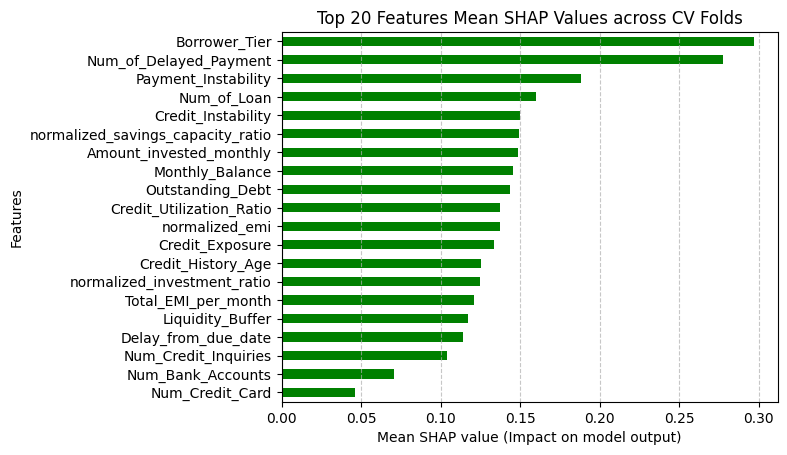

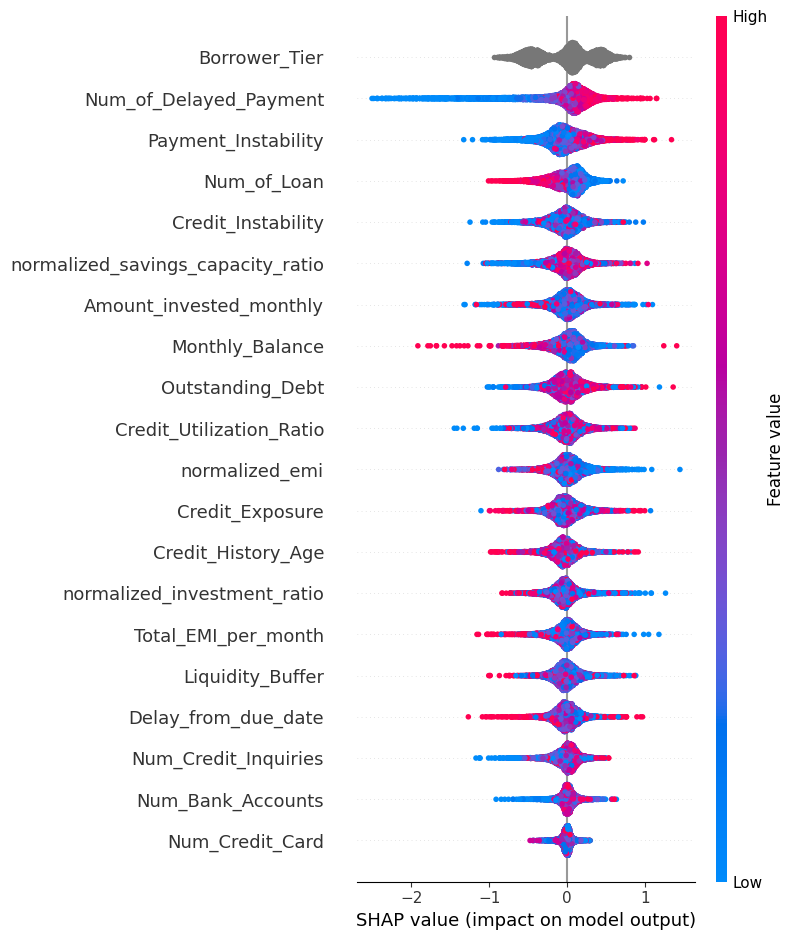

In [135]:
folds = StratifiedKFold(n_splits=7, shuffle=True, random_state=42)
shap_values_list = []

for train_idx, val_idx in folds.split(X,y):

    xgb_m = XGBClassifier(enable_categorical=True, tree_method="hist").fit(X.iloc[train_idx], y.iloc[train_idx])

    explainer = shap.TreeExplainer(xgb_m)
    shap_fold = explainer.shap_values(X.iloc[val_idx])
    shap_values_list.append(shap_fold)

all_shap = np.vstack(shap_values_list)
mean_shap = np.abs(all_shap).mean(axis=0)

feature_importance = pd.Series(mean_shap, index=X.columns).sort_values(ascending=False)

#print("Top Features - Mean Absolute SHAP values:")
#print(feature_importance)

plt.Figure(figsize=(10, 6))
feature_importance.head(20).plot(kind="barh", color="green").invert_yaxis()
plt.title("Top 20 Features Mean SHAP Values across CV Folds")
plt.xlabel("Mean SHAP value (Impact on model output)")
plt.ylabel("Features")
plt.grid(axis="x", linestyle="--", alpha=0.7)
plt.show()

shap.summary_plot(all_shap, X.iloc[np.concatenate([v for _, v in folds.split(X,y)])])

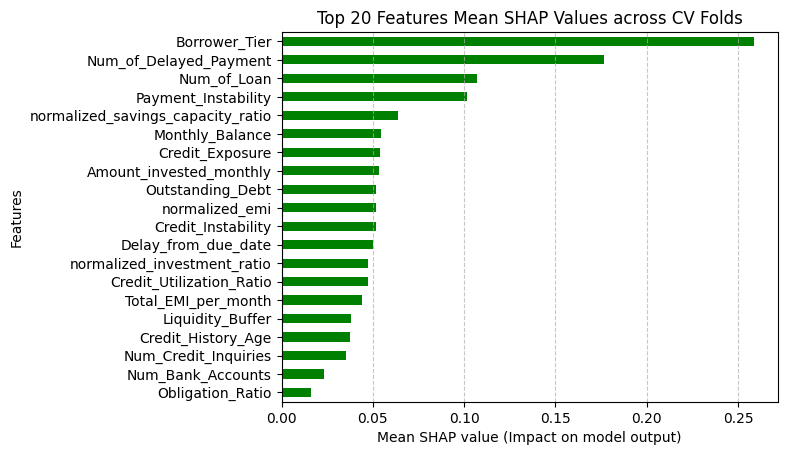

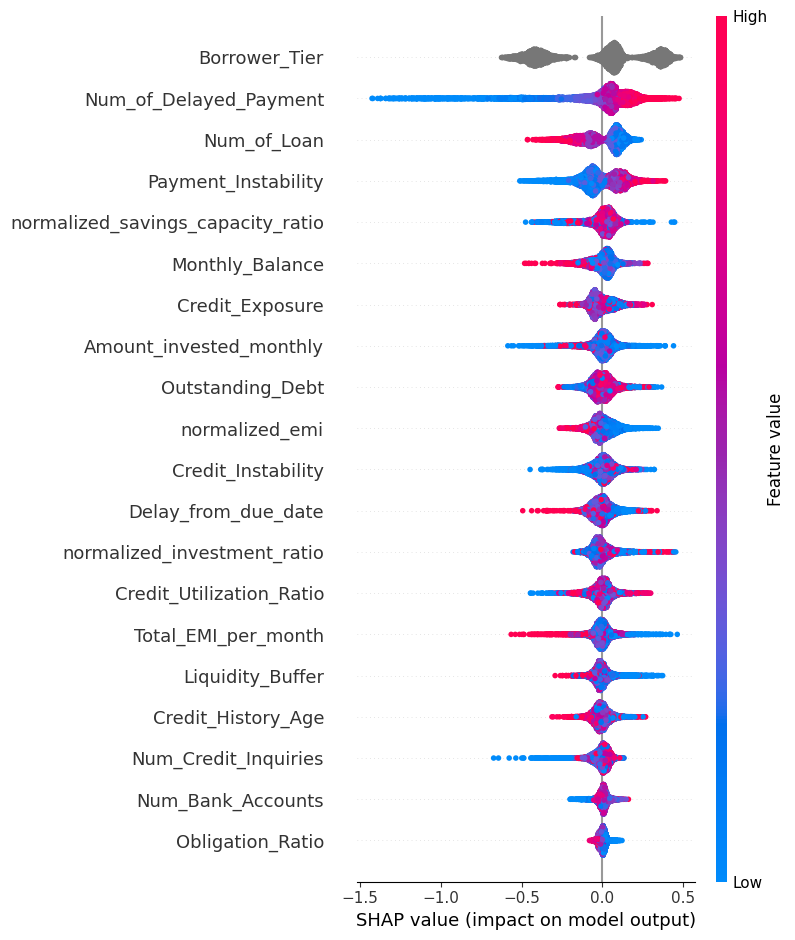

In [136]:
folds = StratifiedKFold(n_splits=7, shuffle=True, random_state=42)
shap_values_list = []

for train_idx, val_idx in folds.split(X,y):

    xgb_m = XGBClassifier(n_estimators=500,
    max_depth=4,
    learning_rate=0.03,
    subsample=0.8,
    #scale_pos_weight=scale_pos_weight,
    colsample_bytree=0.8,
    min_child_weight=5,
    gamma=0.1,
    reg_alpha=0.5,
    enable_categorical=True, 
    tree_method="hist",
    reg_lambda=1.5,
    max_delta_step=1,
    random_state=42).fit(X.iloc[train_idx], y.iloc[train_idx])

    explainer = shap.TreeExplainer(xgb_m)
    shap_fold = explainer.shap_values(X.iloc[val_idx])
    shap_values_list.append(shap_fold)

all_shap = np.vstack(shap_values_list)
mean_shap = np.abs(all_shap).mean(axis=0)

feature_importance = pd.Series(mean_shap, index=X.columns).sort_values(ascending=False)

#print("Top Features - Mean Absolute SHAP values:")
#print(feature_importance)

plt.Figure(figsize=(10, 6))
feature_importance.head(20).plot(kind="barh", color="green").invert_yaxis()
plt.title("Top 20 Features Mean SHAP Values across CV Folds")
plt.xlabel("Mean SHAP value (Impact on model output)")
plt.ylabel("Features")
plt.grid(axis="x", linestyle="--", alpha=0.7)
plt.show()

shap.summary_plot(all_shap, X.iloc[np.concatenate([v for _, v in folds.split(X,y)])])